### **Importing Libraries**

In [1]:
import os
from pathlib import Path
import pywt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import mne
from mne.io import Raw
from mne import Epochs, find_events, pick_types
from mne.filter import filter_data
from mne.time_frequency import psd_array_welch
from mne_connectivity import spectral_connectivity_epochs
from tensorpac import Pac

# Set log-level to reduce verbosity
mne.set_log_level("WARNING")

### **Loading Sample Data**

In [2]:
# Directory where preprocessed `.fif` files are stored
save_dir = "processed_epochs"  # Update to your save directory
base_dir = "ds005545-download"

In [3]:

def log(message):
    """Logging function with timestamps."""
    print(f"[{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {message}")

# 1. Configurable Parameters
CONFIG = {
    "num_subjects": 1,  # Number of subjects to process (set None for all)
    "apply_wavelet": True,  # Whether to apply wavelet denoising
    "tmin": -0.2,  # Start time for epochs
    "tmax": 0.5,  # End time for epochs
    "l_freq": 0.1,  # Lower bound for band-pass filter
    "h_freq": 150.0,  # Upper bound for band-pass filter
    "notch_filter": True,  # Apply notch filter for powerline noise
    "notch_freqs": 50,  # Base frequency for notch filtering (e.g., 50/60 Hz)
    "wavelet_params": {  # Wavelet denoising parameters
        "wavelet": "db4",
        "level": 2,
    },
    "save_dir": save_dir,  # Directory to save processed epochs
    "base_dir": base_dir,  # Dataset directory
}

# 2. Wavelet Denoising Function
def wavelet_denoising(data, wavelet="sym8", level=3, threshold_factor=0.3):
    """
    Applies adaptive wavelet denoising to EEG data with softer thresholding.

    Parameters:
    - data (np.array): EEG signal with shape (epochs, channels, timepoints).
    - wavelet (str): Type of wavelet to use (default: "sym8" for smoothness).
    - level (int): Decomposition level (higher = more noise removal).
    - threshold_factor (float): Lower value = softer denoising.

    Returns:
    - np.array: Denoised EEG data with the same shape.
    """
    denoised_data = []

    for epoch in data:
        denoised_epoch = []
        for ch_data in epoch:
            # Wavelet decomposition
            coeffs = pywt.wavedec(ch_data, wavelet, level=level)

            # Adaptive thresholding: scale based on detail coefficient variance
            thresholded_coeffs = []
            for i, c in enumerate(coeffs):
                if i == 0:  # Approximation coefficients (keep unchanged)
                    thresholded_coeffs.append(c)
                else:  # Detail coefficients (apply adaptive soft thresholding)
                    threshold = threshold_factor * np.std(c)
                    thresholded_coeffs.append(pywt.threshold(c, threshold, mode="soft"))

            # Wavelet reconstruction
            rec = pywt.waverec(thresholded_coeffs, wavelet)
            rec = rec[: len(ch_data)]  # Ensure length consistency
            denoised_epoch.append(rec)

        denoised_data.append(np.array(denoised_epoch))

    return np.array(denoised_data)

# 3. Main Preprocessing Pipeline
def preprocess_subject(subject_path, config):
    log(f"Processing subject: {subject_path.name}")

    for session in sorted(subject_path.glob("ses-*/ieeg")):
        edf_files = list(session.glob("*.edf"))
        for edf_file in edf_files:
            log(f"Loading iEEG data: {edf_file}")
            raw = mne.io.read_raw_edf(edf_file, preload=True)

            # Apply band-pass filtering
            if config["l_freq"] or config["h_freq"]:
                log(f"Applying band-pass filter: {config['l_freq']}–{config['h_freq']} Hz")
                raw.filter(config["l_freq"], config["h_freq"], fir_design="firwin")

            # Apply notch filter
            if config["notch_filter"]:
                nyquist_freq = raw.info["sfreq"] / 2
                notch_freqs = np.arange(config["notch_freqs"], nyquist_freq, config["notch_freqs"])
                log(f"Applying notch filter at {notch_freqs} Hz")
                raw.notch_filter(freqs=notch_freqs, picks="all", filter_length="auto")
                log(f"Sampling frequency: {raw.info['sfreq']} Hz")

            # Extract events
            events, event_id = mne.events_from_annotations(raw)
            log(f"Number of events extracted: {len(events)}")
            log(f"Event mapping: {event_id}")


            # Handle duplicate event times
            try:
                epochs = mne.Epochs(
                    raw,
                    events,
                    event_id,
                    tmin=config["tmin"],
                    tmax=config["tmax"],
                    baseline=(None, 0),
                    preload=True,
                    event_repeated="merge"
                )
                log(f"Number of epochs created: {len(epochs)}")
                log(f"Epochs shape: {epochs.get_data().shape}")
            except RuntimeError as e:
                log(f"Error creating epochs: {e}")
                continue

            # Optional: Wavelet denoising
            if config["apply_wavelet"]:
                log("Applying wavelet denoising...")
                data = epochs.get_data()
                denoised_data = wavelet_denoising(
                    data, wavelet=config["wavelet_params"]["wavelet"], level=config["wavelet_params"]["level"]
                )
            else:
                denoised_data = epochs.get_data()

            # Save preprocessed epochs
            output_dir = Path(config["save_dir"]) / subject_path.name
            if not output_dir.exists():
                output_dir.mkdir(parents=True)
            
            output_file = output_dir / f"{edf_file.stem}_processed-epo.fif"
            epochs.save(output_file, overwrite=True)
            log(f"Saved preprocessed epochs to {output_file}")

            # Verify saved epochs
            loaded_epochs = mne.read_epochs(output_file, preload=True)
            log(f"Reloaded epochs: {loaded_epochs}")

# 4. Execution Script
def main(config):
    base_path = Path(config["base_dir"])

    # Get subjects and limit to the configured number
    subjects = sorted(base_path.glob("sub-*"))
    if config["num_subjects"]:
        subjects = subjects[: config["num_subjects"]]

    log(f"Processing {len(subjects)} subjects...")
    for subject in subjects:
        preprocess_subject(subject, config)

if __name__ == "__main__":
    main(CONFIG)


[2025-02-04 16:49:28] Processing 1 subjects...
[2025-02-04 16:49:28] Processing subject: sub-01
[2025-02-04 16:49:28] Loading iEEG data: ds005545-download\sub-01\ses-01\ieeg\sub-01_ses-01_task-auditory_run-01_ieeg.edf
[2025-02-04 16:49:28] Applying band-pass filter: 0.1–150.0 Hz
[2025-02-04 16:49:33] Applying notch filter at [ 50. 100. 150. 200. 250. 300. 350. 400. 450.] Hz
[2025-02-04 16:49:35] Sampling frequency: 1000.0 Hz
[2025-02-04 16:49:35] Number of events extracted: 183
[2025-02-04 16:49:35] Event mapping: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}
[2025-02-04 16:49:35] Number of epochs created: 183
[2025-02-04 16:49:35] Epochs shape: (183, 66, 701)
[2025-02-04 16:49:35] Applying wavelet denoising...
[2025-02-04 16:49:43] Saved preprocessed epochs to processed_epochs\sub-01\sub-01_ses-01_task-auditory_run-01_ieeg_processed-epo.fif
[2025-02-04 16:49:43] Reloaded epochs: <EpochsFIF | 183 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~64.7 MiB, data loaded,
 '

In [4]:
from pathlib import Path
import mne

def load_epochs(subject_id, save_dir="processed_epochs", file_filter="*_processed-epo.fif"):
    """
    Load epochs for a given subject, ensuring annotations are preserved by keeping epochs separate.

    Parameters:
    - subject_id (str): Subject identifier (e.g., "sub-01").
    - save_dir (str): Directory where processed epochs are stored.
    - file_filter (str): Pattern to match specific `.fif` files.

    Returns:
    - epochs_list (list of mne.Epochs): List of epochs objects (one per file).
    """
    subject_path = Path(save_dir) / subject_id
    if not subject_path.exists():
        raise FileNotFoundError(f"Directory for {subject_id} not found in {save_dir}!")

    fif_files = sorted(subject_path.glob(file_filter))
    if not fif_files:
        raise FileNotFoundError(f"No `.fif` files found for {subject_id} in {subject_path}.")

    epochs_list = []
    missing_channels = set()

    for f in fif_files:
        try:
            epochs = mne.read_epochs(f, preload=True)
            print(f"Loaded: {f.name} | {len(epochs)} epochs | {epochs.info['nchan']} channels")
            epochs_list.append(epochs)
        except Exception as e:
            print(f"Error loading {f.name}: {e}")

    if not epochs_list:
        raise ValueError("No epochs loaded. Check files and filters.")

    # Find channels present in all files
    common_channels = set(epochs_list[0].ch_names)
    for e in epochs_list[1:]:
        common_channels.intersection_update(e.ch_names)

    if not common_channels:
        raise ValueError("No common channels found across all sessions!")

    # Convert to a sorted list (better readability)
    common_channels = sorted(common_channels)

    # Warn if channels are missing
    all_channels = set.union(*(set(e.ch_names) for e in epochs_list))
    missing_channels = all_channels - set(common_channels)
    
    if missing_channels:
        print(f"⚠️ Warning: Some channels are missing across sessions: {len(missing_channels)}")

    # Pick only common channels in each epochs object
    for i in range(len(epochs_list)):
        epochs_list[i].pick(common_channels)

    print(f"✅ Successfully loaded {len(epochs_list)} separate epochs objects.")
    
    return epochs_list  # No concatenation, keeping them separate


In [5]:
from pathlib import Path
import mne

def load_epochs(subject_id, save_dir="processed_epochs", file_filter="*_processed-epo.fif"):
    """
    Load epochs for a given subject, ensuring all sessions have a consistent channel structure 
    without filling missing channels with zeros.

    Parameters:
    - subject_id (str): Subject identifier (e.g., "sub-01").
    - save_dir (str): Directory where processed epochs are stored.
    - file_filter (str): Pattern to match specific `.fif` files.

    Returns:
    - epochs_list (list of mne.Epochs): List of epochs objects with unified channels.
    """
    subject_path = Path(save_dir) / subject_id
    if not subject_path.exists():
        raise FileNotFoundError(f"Directory for {subject_id} not found in {save_dir}!")

    fif_files = sorted(subject_path.glob(file_filter))
    if not fif_files:
        raise FileNotFoundError(f"No `.fif` files found for {subject_id} in {subject_path}.")

    epochs_list = []
    all_channels = set()

    # Load all epochs and collect all unique channel names
    for f in fif_files:
        try:
            epochs = mne.read_epochs(f, preload=True)
            print(f"Loaded: {f.name} | {len(epochs)} epochs | {epochs.info['nchan']} channels")
            epochs_list.append(epochs)
            all_channels.update(epochs.ch_names)  # Collect unique channels
        except Exception as e:
            print(f"Error loading {f.name}: {e}")

    if not epochs_list:
        raise ValueError("No epochs loaded. Check files and filters.")

    all_channels = sorted(all_channels)  # Sort for consistency
    print(f"ℹ️ Total unique channels across sessions: {len(all_channels)}")

    # Ensure all epochs have a consistent channel order without filling missing ones
    for i, epochs in enumerate(epochs_list):
        existing_channels = epochs.ch_names
        missing_channels = list(set(all_channels) - set(existing_channels))
        
        if missing_channels:
            print(f"⚠️ {fif_files[i].name}: {len(missing_channels)} channels missing (not filled)")
        
        # Pick channels that are available without adding new ones
        common_channels = [ch for ch in all_channels if ch in existing_channels]
        epochs_list[i] = epochs.pick_channels(common_channels, ordered=True)

    print(f"✅ Successfully loaded {len(epochs_list)} epochs objects with a consistent channel structure.")
    
    return epochs_list


In [6]:
epochs = load_epochs("sub-01")  

Loaded: sub-01_ses-01_task-auditory_run-01_ieeg_processed-epo.fif | 183 epochs | 66 channels
Loaded: sub-01_ses-02_task-auditory_run-01_ieeg_processed-epo.fif | 183 epochs | 11 channels
Loaded: sub-01_ses-03_task-auditory_run-01_ieeg_processed-epo.fif | 183 epochs | 58 channels
ℹ️ Total unique channels across sessions: 131
⚠️ sub-01_ses-01_task-auditory_run-01_ieeg_processed-epo.fif: 65 channels missing (not filled)
⚠️ sub-01_ses-02_task-auditory_run-01_ieeg_processed-epo.fif: 120 channels missing (not filled)
⚠️ sub-01_ses-03_task-auditory_run-01_ieeg_processed-epo.fif: 73 channels missing (not filled)
✅ Successfully loaded 3 epochs objects with a consistent channel structure.


In [7]:
# Selecting a Specific Session (Since epochs is a list, you can access a specific session using indexing)

epochs_ses_1 = epochs[0]  # First session (ses-01)
epochs_ses_2 = epochs[1]  # Second session (ses-02)
epochs_ses_3 = epochs[2]  # Third session (ses-03)


In [8]:
epochs_ses_1

<EpochsFIF | 183 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~64.7 MiB, data loaded,
 'Trigger-401': 61
 'Trigger-402': 61
 'Trigger-501': 61>

Checking Basic Info About an Epochs Object


###### epochs_ses_1.info  # Summary of metadata (channels, sampling rate, etc.)
###### epochs_ses_1.event_id  # Dictionary mapping event labels to event codes
###### epochs_ses_1.events  # NumPy array with event timing info
###### epochs_ses_1.ch_names  # List of channel names
###### epochs_ses_1.times  # Time points for each epoch
###### epochs_ses_1.get_data().shape  # Shape: (n_epochs, n_channels, n_times)


In [9]:
print("===== SESSION 1 DETAILS =====")

# Print metadata summary
print("\n--- Metadata Info ---")
print(epochs_ses_1.info)

# Print event ID mapping
print("\n--- Event ID Mapping ---")
print(epochs_ses_1.event_id)

# Print channel names
print("\n--- Channel Names ---")
print(epochs_ses_1.ch_names)

# Print shape of the epochs data
print("\n--- Epochs Data Shape ---")
print(epochs_ses_1.get_data().shape)


===== SESSION 1 DETAILS =====

--- Metadata Info ---
<Info | 10 non-empty values
 bads: []
 ch_names: POL A1-A2, POL A10-A11, POL A11-A12, POL A12-A13, POL A13-A14, ...
 chs: 66 EEG
 custom_ref_applied: False
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 lowpass: 150.0 Hz
 meas_date: 2000-01-01 00:00:00 UTC
 meas_id: 4 items (dict)
 nchan: 66
 projs: []
 sfreq: 1000.0 Hz
 subject_info: <subject_info | his_id: 0, last_name: Name, first_name: No, birthday: 1800-01-01, sex: 2>
>

--- Event ID Mapping ---
{'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}

--- Channel Names ---
['POL A1-A2', 'POL A10-A11', 'POL A11-A12', 'POL A12-A13', 'POL A13-A14', 'POL A14-A15', 'POL A15-A16', 'POL A17-A18', 'POL A18-A19', 'POL A19-A20', 'POL A2-A3', 'POL A20-A21', 'POL A21-A22', 'POL A22-A23', 'POL A23-A24', 'POL A25-A26', 'POL A25-A33', 'POL A26-A27', 'POL A26-A34', 'POL A27-A28', 'POL A27-A35', 'POL A28-A29', 'POL A28-A36', 'POL A29-A30', 'POL A29-A37', 'POL A3-A4', 'POL A30-A31', 'POL A30-A38', 'P

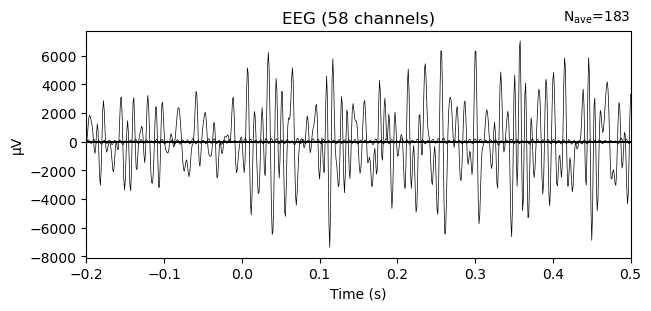

In [10]:
epochs_ses_3.average().plot();



C:\Users\lacom\AppData\Local\Temp\ipykernel_372\4282426093.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  epochs_ses_1.plot_psd();
c:\Users\lacom\.conda\envs\xtra\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


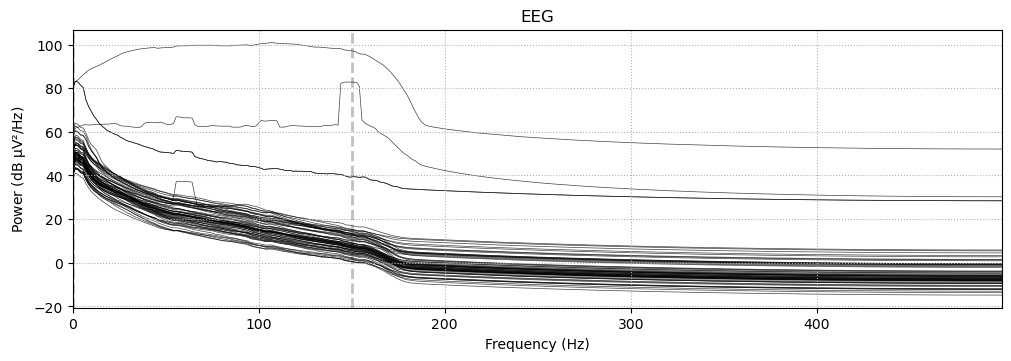

In [11]:
epochs_ses_1.plot_psd();


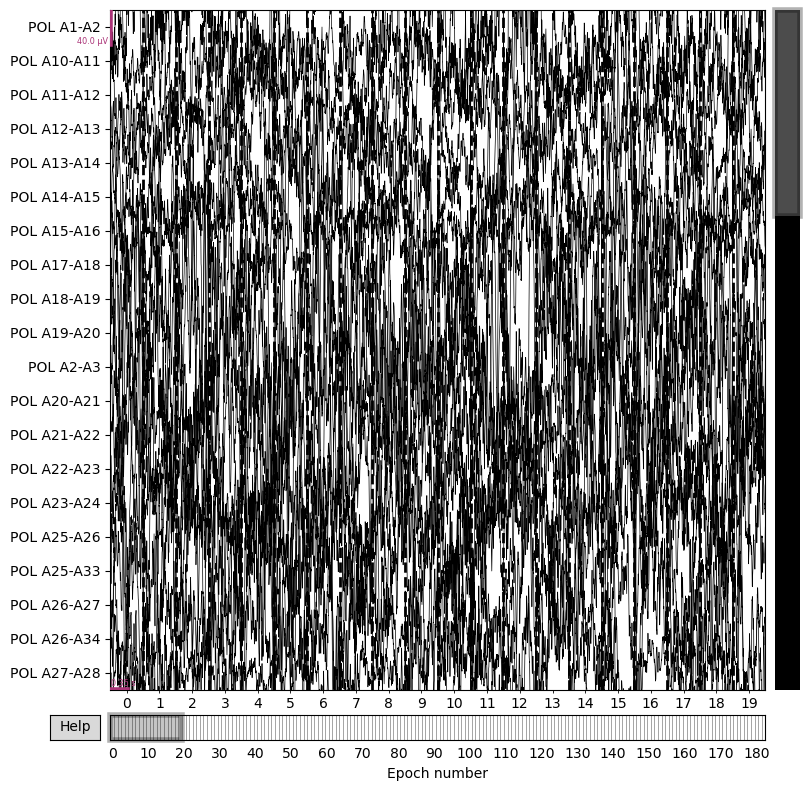

In [12]:
epochs_ses_1.plot();


In [13]:
# Extracting Events
def get_events_from_epochs(epochs):
    """
    Retrieve events and event IDs from an mne.Epochs object.
    
    Parameters:
    - epochs: An mne.Epochs object.
    
    Returns:
    - events: The events array (shape: n_events x 3).
    - event_id: A dictionary mapping event names to event IDs.
    """
    events = epochs.events  # Shape: (n_events, 3)
    event_id = epochs.event_id  # Dictionary: {event_name: event_code}
    return events, event_id

# Retrieve events for each epochs file
for i, epochs in enumerate(epochs):
    print(f"File {i + 1}:")
    events, event_id = get_events_from_epochs(epochs)
    print(f"  Events shape: {events.shape}")
    print(f"  Event IDs: {event_id}")



File 1:
  Events shape: (183, 3)
  Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}
File 2:
  Events shape: (183, 3)
  Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}
File 3:
  Events shape: (183, 3)
  Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}


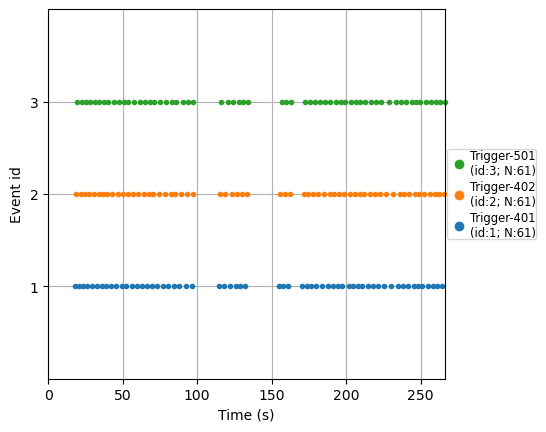

In [14]:
# Visualize events 
event_conditions = ['Trigger-401', 'Trigger-402', 'Trigger-501']  # Example event conditions

event1 = 'Trigger-401'
event2 = 'Trigger-402'
event3 = 'Trigger-501'

sfreq = epochs.info['sfreq']


fig = mne.viz.plot_events(events, sfreq=sfreq, event_id=event_id);

### **Compute connectivity**

In [29]:
from mne_connectivity import spectral_connectivity_epochs
from itertools import combinations


def compute_connectivity_per_session(epochs_list, bands, subject_id):
    """
    Compute spectral connectivity for each session, preserving events and epochs.
    
    For each session (an mne.Epochs object):
      1. Checks if there are at least 2 channels (since connectivity requires pairs).
      2. Retrieves events and event IDs.
      3. Identifies unique event codes and maps them to their event names.
      4. Generates channel pairs using combinations.
      5. Computes connectivity for each event and each frequency band.
      6. Stores results in a DataFrame.
    
    Parameters:
      - epochs_list: List of mne.Epochs objects, one per session.
      - bands: Dictionary mapping band names to frequency ranges, e.g., {"alpha": (8, 12), "beta": (13, 30)}.
      - subject_id: A string identifier for the subject (e.g., "sub-01").
    
    Returns:
      - session_dfs: A dictionary where keys are session IDs (e.g., "ses-01") and values are DataFrames
                     containing the connectivity data.
    """
    session_dfs = {}

    for session_idx, epochs in enumerate(epochs_list):
        session_id = f"ses-{session_idx+1:02d}"
        ch_names = epochs.ch_names

        if len(ch_names) < 2:
            print(f"⚠️ Skipping {session_id} (insufficient channels)")
            continue

        print(f"\n🔹 Processing {subject_id}, {session_id} ({len(ch_names)} channels)")

        # Retrieve events and event IDs
        events_array, event_id = get_events_from_epochs(epochs)
        print(f"   - Events shape: {events_array.shape}")
        print(f"   - Event IDs: {event_id}")

        # Extract event codes (third column of events_array) and find unique ones.
        event_codes = events_array[:, 2]
        unique_event_codes = np.unique(event_codes)
        print(f"   - Found {len(unique_event_codes)} unique event codes: {unique_event_codes}")

        # Generate all possible unique channel pairs.
        valid_pairs = list(combinations(range(len(ch_names)), 2))
        indices = tuple(np.array(valid_pairs).T)
        pair_names = [f"{ch_names[i]}-{ch_names[j]}" for i, j in valid_pairs]

        session_data = []

        # Process each unique event code.
        for code in unique_event_codes:
            # Map the event code to an event name.
            event_name = None
            for name, event_code in event_id.items():
                if event_code == code:
                    event_name = name
                    break
            
            if event_name is None:
                print(f"⚠️ No matching event name found for event code {code} in {session_id}")
                continue

            # Extract epochs corresponding to this event.
            event_epochs = epochs[event_name]
            if len(event_epochs) == 0:
                print(f"⚠️ No epochs for event {event_name} in {session_id}")
                continue

            conn_results = {}
            # Compute connectivity for each frequency band.
            for band_name, (fmin, fmax) in bands.items():
                conn = spectral_connectivity_epochs(
                    event_epochs,
                    method='wpli2_debiased',
                    mode='multitaper',
                    sfreq=event_epochs.info['sfreq'],
                    fmin=fmin,
                    fmax=fmax,
                    faverage=True,
                    indices=indices
                )
                # Get the connectivity data and remove unnecessary dimensions.
                # Note: if there's only one epoch, squeezing can make the array 1D.
                data = conn.get_data().squeeze()
                conn_results[band_name] = data

            # For each epoch, build a row with connectivity values.
            for epoch_idx in range(len(event_epochs)):
                row = {
                    "subject": subject_id,
                    "session": session_id,
                    "event": event_name,
                    "epoch": epoch_idx
                }
                for band_name, data in conn_results.items():
                    for pair_idx, pair_name in enumerate(pair_names):
                        # Check if the data array is 1-dimensional.
                        # Math analogy: If you have only one row, your "matrix" is actually a vector.
                        if data.ndim == 1:
                            # If one epoch exists, we access the value directly.
                            value = data[pair_idx]
                        else:
                            # For multiple epochs, index using [epoch_idx, pair_idx]
                            value = data[epoch_idx, pair_idx]
                        row[f"{pair_name}_{band_name}"] = value
                session_data.append(row)

        # Combine all rows into a DataFrame for this session.
        session_df = pd.DataFrame(session_data)
        session_dfs[session_id] = session_df

    return session_dfs


In [30]:
bands = {
    "Alpha": (8, 12),
    "Beta": (12, 30),
    "Gamma": (30, 50)
}

# Load your epochs (replace with your actual data loading)
epochs_list = load_epochs("sub-01")  
subject_id = "sub-01"

# Compute connectivity
session_dfs = compute_connectivity_per_session(epochs_list, bands, "sub-01")

# Save DataFrames
for session_id, df in session_dfs.items():
    filename = f"{subject_id}_{session_id}_connectivity.csv"
    df.to_csv(filename, index=False)
    print(f"✅ Saved {filename}")

Loaded: sub-01_ses-01_task-auditory_run-01_ieeg_processed-epo.fif | 183 epochs | 66 channels
Loaded: sub-01_ses-02_task-auditory_run-01_ieeg_processed-epo.fif | 183 epochs | 11 channels
Loaded: sub-01_ses-03_task-auditory_run-01_ieeg_processed-epo.fif | 183 epochs | 58 channels
ℹ️ Total unique channels across sessions: 131
⚠️ sub-01_ses-01_task-auditory_run-01_ieeg_processed-epo.fif: 65 channels missing (not filled)
⚠️ sub-01_ses-02_task-auditory_run-01_ieeg_processed-epo.fif: 120 channels missing (not filled)
⚠️ sub-01_ses-03_task-auditory_run-01_ieeg_processed-epo.fif: 73 channels missing (not filled)
✅ Successfully loaded 3 epochs objects with a consistent channel structure.

🔹 Processing sub-01, ses-01 (66 channels)
   - Events shape: (183, 3)
   - Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigger-501': 3}
   - Found 3 unique event codes: [1 2 3]

🔹 Processing sub-01, ses-02 (11 channels)
   - Events shape: (183, 3)
   - Event IDs: {'Trigger-401': 1, 'Trigger-402': 2, 'Trigg

In [31]:
# Example: Load a single CSV file
filename = "sub-01_ses-01_connectivity.csv"
df = pd.read_csv(filename)

# Display the first few rows
df.head()

,subject,session,event,epoch,POL A1-A2-POL A10-A11_Alpha,POL A1-A2-POL A11-A12_Alpha,POL A1-A2-POL A12-A13_Alpha,POL A1-A2-POL A13-A14_Alpha,POL A1-A2-POL A14-A15_Alpha,POL A1-A2-POL A15-A16_Alpha,...,POL A6-A7-POL A7-A8_Gamma,POL A6-A7-POL A9-A10_Gamma,POL A6-A7-POL DC01_Gamma,POL A6-A7-POL DC02_Gamma,POL A7-A8-POL A9-A10_Gamma,POL A7-A8-POL DC01_Gamma,POL A7-A8-POL DC02_Gamma,POL A9-A10-POL DC01_Gamma,POL A9-A10-POL DC02_Gamma,POL DC01-POL DC02_Gamma
0,sub-01,ses-01,Trigger-401,0,-0.010813,0.039986,-0.002295,-0.020968,0.028079,-0.012217,...,-0.009815,0.003614,-0.020073,0.066786,0.001261,0.00537,0.011194,-0.024309,-0.016614,0.00723
1,sub-01,ses-01,Trigger-401,1,-0.010813,0.039986,-0.002295,-0.020968,0.028079,-0.012217,...,-0.009815,0.003614,-0.020073,0.066786,0.001261,0.00537,0.011194,-0.024309,-0.016614,0.00723
2,sub-01,ses-01,Trigger-401,2,-0.010813,0.039986,-0.002295,-0.020968,0.028079,-0.012217,...,-0.009815,0.003614,-0.020073,0.066786,0.001261,0.00537,0.011194,-0.024309,-0.016614,0.00723
3,sub-01,ses-01,Trigger-401,3,-0.010813,0.039986,-0.002295,-0.020968,0.028079,-0.012217,...,-0.009815,0.003614,-0.020073,0.066786,0.001261,0.00537,0.011194,-0.024309,-0.016614,0.00723
4,sub-01,ses-01,Trigger-401,4,-0.010813,0.039986,-0.002295,-0.020968,0.028079,-0.012217,...,-0.009815,0.003614,-0.020073,0.066786,0.001261,0.00537,0.011194,-0.024309,-0.016614,0.00723


### **Electrode positions**

In [15]:
# Load electrode metadata
electrodes_tsv = 'ds005545-download/sub-80/ses-01/ieeg/sub-80_ses-01_electrodes.tsv'
electrode_positions = pd.read_csv(electrodes_tsv, sep='\t')

# Display electrode positions
print(electrode_positions.head())

  name          x          y          z  size
0   A3 -50.106579 -58.395985  23.277752     0
1   A4 -59.254402 -54.785877  15.215353     0
2   A5 -59.978233 -40.066578  39.257343     0
3   A6 -45.325970 -28.038254  37.129173     0
4   A7 -54.598400 -25.692129  44.675392     0


In [16]:
from mne.datasets import fetch_fsaverage
from mne.transforms import Transform, apply_trans


# Prepare electrode positions for MNE montage
elec_names = electrode_positions['name'].values.tolist()  # Convert to a list
elec_positions = electrode_positions[['x', 'y', 'z']].values / 1000  # Convert from mm to meters

# Define fiducial points for head coordinates (replace with actual positions in meters)
fiducials = {
    'nasion': np.array([0, 0.1, 0]),
    'lpa': np.array([-0.1, 0, 0]),
    'rpa': np.array([0.1, 0, 0]),
}

# Combine fiducial and electrode positions
ch_pos = {name: pos for name, pos in zip(elec_names, elec_positions)}
ch_pos.update(fiducials)  # Add fiducials to channel positions

# Create a montage with fiducials
montage = mne.channels.make_dig_montage(
    ch_pos=ch_pos,
    coord_frame='head'  # Use 'head' as the coordinate frame
)

# Create an `info` object for the electrodes
info = mne.create_info(
    ch_names=elec_names,
    sfreq=1000,  # Replace with your sampling frequency
    ch_types="seeg"  # Specify the channel type
)
info.set_montage(montage)  # Set the montage to the info object

# Fetch fsaverage template for visualization
sample_path = mne.datasets.sample.data_path()
subjects_dir = sample_path / "subjects"
fetch_fsaverage(subjects_dir=subjects_dir, verbose=True)

# Perform coregistration to compute head->MRI transform
trans = mne.transforms.Transform(
    fro="head", to="mri", trans=np.eye(4)  # Identity matrix as a placeholder
)  # Replace with a valid coregistration matrix if available

# Visualize electrode positions on fsaverage
brain = mne.viz.Brain(
    "fsaverage",
    subjects_dir=subjects_dir,
    cortex="low_contrast",
    alpha=0.25,
    background="white",
)

# Add electrodes to the brain visualization
brain.add_sensors(info, trans=trans)  # Use the computed transformation

# Show the view
brain.show_view(azimuth=120, elevation=100, distance=400)

# **Apply the Transformation to the Montage (Important Step)**
# Extract the electrode positions
ch_pos = montage.get_positions()['ch_pos']

# Apply the head-to-MRI transform to each electrode
transformed_positions = {}
for ch_name, pos in ch_pos.items():
    # Apply the transformation to each electrode position
    transformed_pos = apply_trans(trans['trans'], pos)
    transformed_positions[ch_name] = transformed_pos

# Update the montage with the transformed positions
montage = mne.channels.make_dig_montage(
    ch_pos=transformed_positions,
    coord_frame='mri'  # Update the coordinate frame to 'mri'
)

# **Now, Get Volume Labels**
# Map electrode positions to anatomical regions
labels, colors = mne.get_montage_volume_labels(
    montage, "fsaverage", subjects_dir=subjects_dir, aseg="aparc+aseg"
)



c:\Users\lacom\.conda\envs\xtra\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


0 files missing from root.txt in C:\Users\lacom\mne_data\MNE-sample-data\subjects
0 files missing from bem.txt in C:\Users\lacom\mne_data\MNE-sample-data\subjects\fsaverage
False


In [17]:
# Accessing and indexing epochs by condition
evoked_1 = epochs['Trigger-401'].average()
evoked_2 = epochs['Trigger-402'].average()

C:\Users\lacom\AppData\Local\Temp\ipykernel_16212\1749978461.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = evoked_1.plot(spatial_colors=True,titles='Evoked 1')


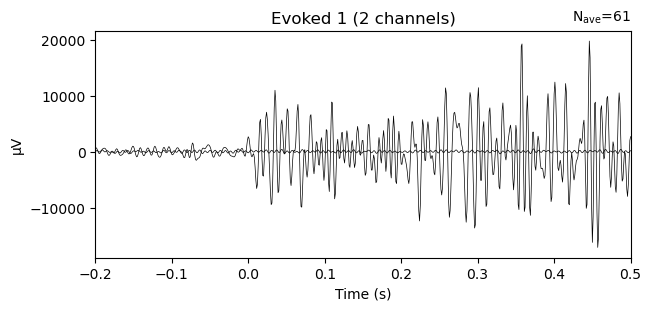

C:\Users\lacom\AppData\Local\Temp\ipykernel_16212\1749978461.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = evoked_2.plot(spatial_colors=True,titles='Evoked 2')


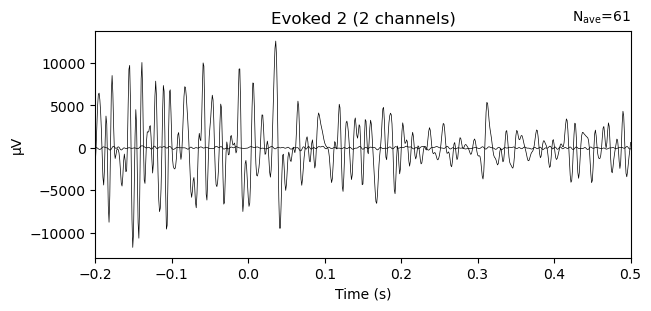

In [18]:
fig = evoked_1.plot(spatial_colors=True,titles='Evoked 1')
fig = evoked_2.plot(spatial_colors=True,titles='Evoked 2')

### Machine Learning

In [32]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from mne.decoding import SlidingEstimator, cross_val_multiscore

In [33]:
# Define the event conditions you want to label
event_conditions = ['Trigger-401', 'Trigger-402', 'Trigger-501'] 

#To keep chance level at 50% accuracy, we first equalize the number of epochs in each condition.
epochs.equalize_event_counts(event_id)

# Separate auditory and visual epochs
Trigger1_epochs = epochs['Trigger-401']
Trigger2_epochs = epochs['Trigger-402']

# Print information about the equalized epochs
print(Trigger1_epochs)
print(Trigger2_epochs)

<EpochsFIF | 61 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~19.0 MiB, data loaded,
 'Trigger-401': 61>
<EpochsFIF | 61 events (all good), -0.2 – 0.5 s (baseline -0.2 – 0 s), ~19.0 MiB, data loaded,
 'Trigger-402': 61>


In [35]:
df.columns

Index(['subject', 'session', 'event', 'epoch', 'POL A1-A2-POL A10-A11_Alpha',
       'POL A1-A2-POL A11-A12_Alpha', 'POL A1-A2-POL A12-A13_Alpha',
       'POL A1-A2-POL A13-A14_Alpha', 'POL A1-A2-POL A14-A15_Alpha',
       'POL A1-A2-POL A15-A16_Alpha',
       ...
       'POL A6-A7-POL A7-A8_Gamma', 'POL A6-A7-POL A9-A10_Gamma',
       'POL A6-A7-POL DC01_Gamma', 'POL A6-A7-POL DC02_Gamma',
       'POL A7-A8-POL A9-A10_Gamma', 'POL A7-A8-POL DC01_Gamma',
       'POL A7-A8-POL DC02_Gamma', 'POL A9-A10-POL DC01_Gamma',
       'POL A9-A10-POL DC02_Gamma', 'POL DC01-POL DC02_Gamma'],
      dtype='object', length=6439)

In [38]:
print("Original labels:", df['event'].unique())

Original labels: ['Trigger-401' 'Trigger-402' 'Trigger-501']


In [41]:
# Define mapping dictionary
remap_dict = {'Trigger-401': 0, 'Trigger-402': 1, 'Trigger-501': 2}

# Apply mapping to convert event labels to integers
df['event'] = df['event'].map(remap_dict).astype(int)


In [47]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Select only columns that contain channel-related names (e.g., contain "POL")
channel_features = [col for col in df.columns if "POL" in col]

# Keep only these columns
X = df[channel_features]  
y = df['event']  # Labels


# Step 1: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [48]:

# Step 2: Define the best hyperparameters based on grid search results
best_params = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 100,
    'subsample': 0.8
}

# Step 3: Set up the XGBoost classifier with the best hyperparameters
xgb = XGBClassifier( 
    eval_metric='mlogloss',
    **best_params  # Apply the best hyperparameters here
)

# Step 4: Fit the XGBoost model on the training data
xgb.fit(X_train, y_train)

# Step 5: Make predictions on the test data
y_pred = xgb.predict(X_test)

# Step 6: Evaluate the model performance using accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with best hyperparameters: {accuracy:.4f}")


Accuracy with best hyperparameters: 1.0000


In [49]:
train_accuracy = accuracy_score(y_train, xgb.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Training Accuracy: 1.0000
Test Accuracy: 1.0000


In [53]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predictions
y_pred = xgb.predict(X_test)
y_pred_probs = xgb.predict_proba(X_test)  # For AUC-ROC

# Compute Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')  # Macro for multi-class
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

# AUC-ROC for multi-class (One-vs-Rest)
roc_auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')

# Print classification report (detailed per class)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Print overall metrics
print(f"\nOverall Test Results:\n"
      f"Accuracy: {accuracy:.4f}\n"
      f"AUC-ROC: {roc_auc:.4f}\n"
      f"Precision (Macro): {precision:.4f}\n"
      f"Recall (Macro): {recall:.4f}\n"
      f"F1 Score (Macro): {f1:.4f}")



Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        13

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37


Overall Test Results:
Accuracy: 1.0000
AUC-ROC: 1.0000
Precision (Macro): 1.0000
Recall (Macro): 1.0000
F1 Score (Macro): 1.0000


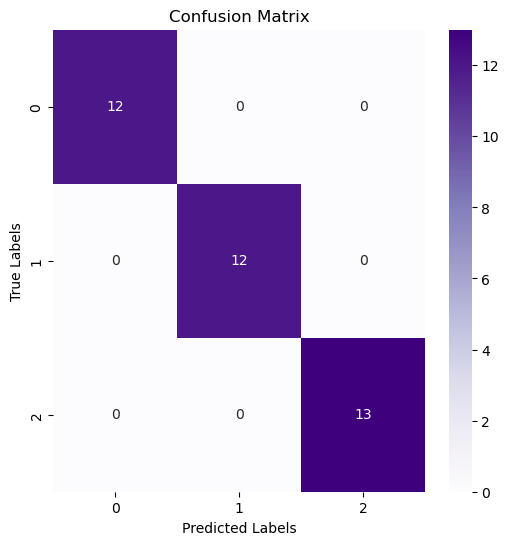

In [54]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Purples", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title('Confusion Matrix')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()


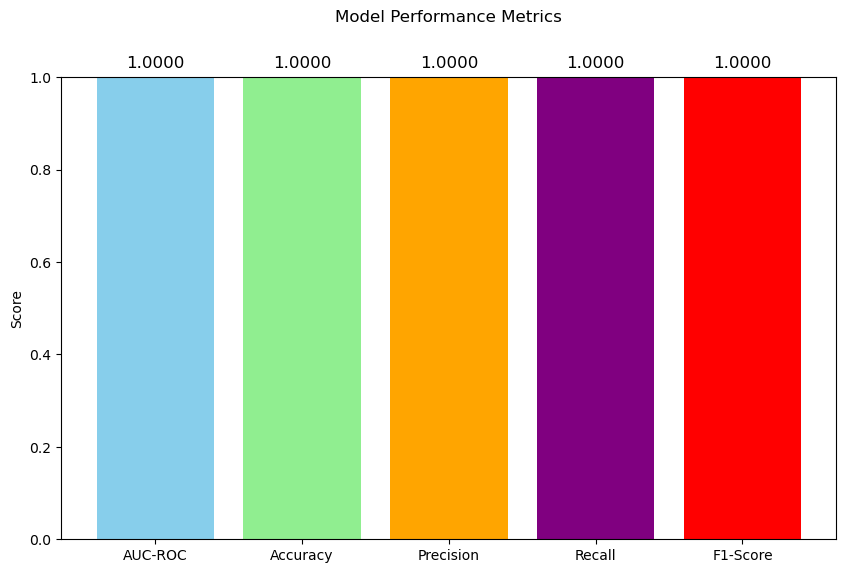

In [57]:
# Metrics Dictionary
metrics = {'AUC-ROC': roc_auc, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}
metric_names = list(metrics.keys())
metric_values = list(metrics.values())

# Plot Metrics Bar Chart
plt.figure(figsize=(10, 6))
plt.bar(metric_names, metric_values, color=['skyblue', 'lightgreen', 'orange', 'purple', 'red'])
plt.title("Model Performance Metrics", pad=40)
plt.ylabel("Score")
plt.ylim(0, 1)  # All scores are between [0, 1]

# Add value annotations
for i, v in enumerate(metric_values):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontsize=12)

plt.show()


In [50]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb, X, y, cv=5, scoring='accuracy')
print(f"Cross-validation accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Cross-validation accuracy: 1.0000 ± 0.0000


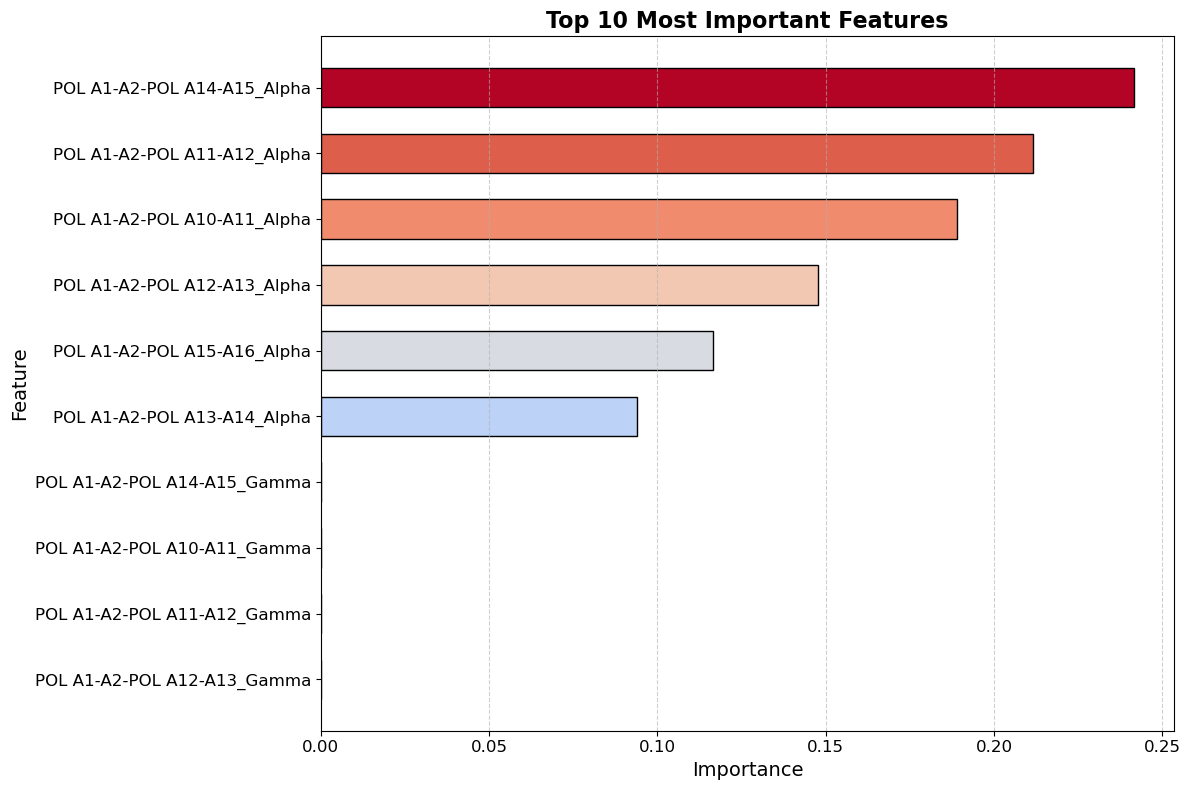

,feature,importance
4,POL A1-A2-POL A14-A15_Alpha,0.241437
1,POL A1-A2-POL A11-A12_Alpha,0.211484
0,POL A1-A2-POL A10-A11_Alpha,0.189064
2,POL A1-A2-POL A12-A13_Alpha,0.147569
5,POL A1-A2-POL A15-A16_Alpha,0.116503
3,POL A1-A2-POL A13-A14_Alpha,0.093943
4294,POL A1-A2-POL A14-A15_Gamma,0.000000
4290,POL A1-A2-POL A10-A11_Gamma,0.000000
4291,POL A1-A2-POL A11-A12_Gamma,0.000000
4292,POL A1-A2-POL A12-A13_Gamma,0.000000


In [51]:
# Get feature importance from the trained model
importances = xgb.feature_importances_

# Step 10: Create a DataFrame of feature importances (with channel-timepoint as the feature names)
feature_importances_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

# Sort the DataFrame by importance
feature_importances_df = feature_importances_df.sort_values(by='importance', ascending=False)

# Step 11: Visualize the top 10 most important features
top_10_features = feature_importances_df.head(10)

# Set up the plot
plt.figure(figsize=(12, 8))

# Create a color palette based on importance values (from light to dark)
bar_colors = sns.color_palette("coolwarm", as_cmap=True)

# Create the horizontal bar plot
bars = plt.barh(top_10_features['feature'], top_10_features['importance'], 
                color=bar_colors(top_10_features['importance'] / max(top_10_features['importance'])), 
                edgecolor='black', height=0.6)


# Make the title and labels more readable
plt.title('Top 10 Most Important Features', fontsize=16, fontweight='bold')
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)

# Invert the y-axis to display the most important feature at the top
plt.gca().invert_yaxis()

# Customize the grid
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Customize ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

# Step 12: Optionally, output the top important features for further analysis
top_10_features
